# ODMR Spectroscopy: Literature-Guided Global Fitting of 8 Hyperfine-Split Resonances

This notebook implements a workflow for fitting ensemble NV-center ODMR spectra 

  
   **Citations:** arXiv:2504.18478 (orientation-dependent CW-ODMR spectra and resolved/overlapping resonances), arXiv:2504.20750 (fit-model comparison and parameter extraction), arXiv:2301.04106 (ODMR transition-strength spectra and resolved 3×8 peak structure).

 **A Voigt option was added and made the default line shape** for the resonance model, while a Lorentzian option is still available for comparison.  
   **Why:** recent NV literature explicitly recommends Voigt fits over pure Gaussian/Lorentzian fits for more accurate linewidth extraction in CW-ODMR when inhomogeneous and power broadening both matter.  
   **Citation:** arXiv:2504.20750.

**Fit uncertainties are propagated from the covariance matrix** and exposed for plotting.  


## Physical context

In a bulk diamond with four NV orientations, a magnetic field generally produces **four resonance pairs** (eight broad ODMR dips). For \(^{14}\mathrm{N}\) centers, each electronic transition is further split into **three hyperfine components**, so a fully resolved spectrum can contain \(3\times 8\) peaks.  
**Citations:** arXiv:2504.18478, arXiv:2301.04106.




This notebook is still designed for the regime where the ODMR spectrum is sufficiently resolved that **4 dips are identifiable on each side of \(D\approx 2.87\) GHz**. Recent work shows that low-bias and overlapping-resonance regimes can become ambiguous and may require a more complete Hamiltonian-based forward model instead of simple peak finding.  
**Citation:** arXiv:2504.18478.


## Import Libraries


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from scipy.signal import savgol_filter, find_peaks
from scipy.optimize import curve_fit
from scipy.special import voigt_profile
import os
import re
from pathlib import Path

# Jupyter-friendly display defaults
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
})

---

## Part 1: Model Functions

### Physical model and literature-guided correction

We model the ODMR spectrum as a superposition of **8 hyperfine triplets**. Each triplet corresponds to one broadened electronic transition and consists of three equally spaced hyperfine components associated with the \(^{14}\mathrm{N}\) nuclear spin \(I=1\). This is consistent with current NV ODMR modeling papers that explicitly describe the \(3\times 8\) structure for four NV classes with two electronic transitions per class.  
**Citations:** arXiv:2301.04106, arXiv:2504.18478.

### Why a Voigt model was added

The original notebook used a pure Lorentzian profile. That is often a reasonable first approximation, but recent NV literature emphasizes that **CW-ODMR line shapes are often neither purely Gaussian nor purely Lorentzian** because both inhomogeneous broadening and power broadening contribute. For that reason, the default model below is now a **Voigt profile**, with a switch back to Lorentzian if you want direct comparison with the original notebook.  
**Citation:** arXiv:2504.20750.

### Global ODMR model

\[
y(f)=1-\sum_{i=1}^{8} C_i\Big[w_{-1}\,\Phi(f;f_{c,i}-\Delta_{\mathrm{hf}})
+w_0\,\Phi(f;f_{c,i})
+w_{+1}\,\Phi(f;f_{c,i}+\Delta_{\mathrm{hf}})\Big],
\]

where \(\Phi\) is either a normalized **Voigt** or **Lorentzian** line shape, \(f_{c,i}\) is the center of the \(i\)-th broad dip, \(C_i\) is its contrast, and \(\Delta_{\mathrm{hf}}\) is a shared \(^{14}\mathrm{N}\) hyperfine splitting. Shared triplet weights are retained as a compact phenomenological model; a full Hamiltonian treatment would be the next step if resonances substantially overlap or mixing becomes important.  
**Citations:** arXiv:2301.04106, arXiv:2504.18478, arXiv:2504.20750.


In [14]:
def lorentzian(x, x0, gamma_fwhm):
    """
    Unit-height Lorentzian line.
    """
    return 1.0 / (1.0 + 4.0 * ((x - x0) / gamma_fwhm) ** 2)


def voigt_unit_height(x, x0, gamma_l_fwhm, sigma_g):
    """
    Unit-height Voigt profile centered at x0.

    Parameters
    ----------
    gamma_l_fwhm : float
        Lorentzian full width at half maximum (GHz).
    sigma_g : float
        Gaussian standard deviation (GHz).

    Notes
    -----
    Recent NV CW-ODMR literature recommends Voigt fits for linewidth extraction
    because both inhomogeneous and power broadening can contribute.
    Citation in notebook text: arXiv:2504.20750.
    """
    gamma_hwhm = gamma_l_fwhm / 2.0
    v = voigt_profile(x - x0, sigma_g, gamma_hwhm)
    v0 = voigt_profile(np.array([0.0]), sigma_g, gamma_hwhm)[0] + 1e-15
    return v / v0


def make_global_odmr_model(line_shape="voigt"):
    """
    Return a curve_fit-compatible global ODMR model.

    Parameters in *params
    ---------------------
    centers (8)
    contrasts (8)
    delta_hf
    width_L
    width_G_or_dummy
    w_m1, w_0, w_p1
    """

    def model(x, *params):
        n_dips = 8
        centers = np.array(params[:n_dips])
        contrasts = np.array(params[n_dips:2 * n_dips])

        delta_hf = params[2 * n_dips]
        width_L = params[2 * n_dips + 1]
        width_G = params[2 * n_dips + 2]

        w_m1 = params[2 * n_dips + 3]
        w_0  = params[2 * n_dips + 4]
        w_p1 = params[2 * n_dips + 5]

        wsum = w_m1 + w_0 + w_p1 + 1e-15
        w_m1 /= wsum
        w_0  /= wsum
        w_p1 /= wsum

        y = np.ones_like(x, dtype=float)

        for fc, C in zip(centers, contrasts):
            if line_shape.lower() == "voigt":
                phi_m1 = voigt_unit_height(x, fc - delta_hf, width_L, width_G)
                phi_0  = voigt_unit_height(x, fc,             width_L, width_G)
                phi_p1 = voigt_unit_height(x, fc + delta_hf, width_L, width_G)
            elif line_shape.lower() == "lorentzian":
                phi_m1 = lorentzian(x, fc - delta_hf, width_L)
                phi_0  = lorentzian(x, fc,             width_L)
                phi_p1 = lorentzian(x, fc + delta_hf, width_L)
            else:
                raise ValueError(f"Unknown line_shape={line_shape!r}")

            triplet = w_m1 * phi_m1 + w_0 * phi_0 + w_p1 * phi_p1
            y -= C * triplet

        return y

    return model


---

## Part 2: Data Preprocessing Functions

### Normalization and smoothing

Before dip detection, the signal is normalized and lightly smoothed with a Savitzky–Golay filter. This does **not** define the fit model itself; it is only used to make initial dip detection more robust.

That correction is kept because smoothing for detection is standard practice, while the actual fit is still performed on the baseline-corrected spectrum rather than on the smoothed trace.  
**Literature note:** recent NV papers distinguish clearly between visual/detection processing and the actual physical forward model used for spectral interpretation.  
**Citations:** arXiv:2504.18478, arXiv:2504.20750.


In [15]:
def normalize_signal(y):
    """
    Normalize raw signal to [0, 1] interval.
    
    Formula:
        y_norm = (y - min(y)) / (max(y) - min(y))
    
    This is used only for detection and visualization.
    The actual fitting is done on baseline-corrected raw data.
    
    Parameters
    ----------
    y : array
        Raw ODMR signal
    
    Returns
    -------
    array
        Normalized signal in [0, 1]
    """
    y = np.asarray(y, dtype=float)
    return (y - np.min(y)) / (np.max(y) - np.min(y) + 1e-15)


def smooth_signal(y, window=9, poly=3):
    """
    Apply Savitzky-Golay smoothing for robust peak detection.
    
    The Savitzky-Golay filter fits a local polynomial to each point,
    preserving the underlying shape while reducing noise.
    
    Parameters
    ----------
    y : array
        Signal to smooth
    window : int
        Smoothing window length (must be odd)
    poly : int
        Polynomial order for local fit
    
    Returns
    -------
    array
        Smoothed signal
    """
    if window % 2 == 0:
        window += 1
    if window >= len(y):
        window = len(y) - 1 if len(y) % 2 == 0 else len(y)
    if window < 5:
        return y.copy()
    return savgol_filter(y, window_length=window, polyorder=poly)


---

## Part 3: Broad ODMR Dip Detection

### Find 4 dips on each side of \(D\)

practical assumption that the measured spectrum contains **4 broad resonances below** and **4 broad resonances above** the zero-field splitting \(D\approx 2.87\) GHz. That is physically appropriate when all four NV orientation classes are resolved and each contributes one \(m_s=0\rightarrow -1\) and one \(m_s=0\rightarrow +1\) transition.  
**Citations:** arXiv:2504.18478, arXiv:2301.04106.



In [16]:
def detect_8_broad_dips(f_ghz, y_norm, D_GHz=2.87, fmin=2.79, fmax=2.96, prominence=0.01):
    """
    Detect the approximate center frequencies of the 8 broad ODMR dips.

    This is intended for the resolved-spectrum regime:
    4 dips below D and 4 dips above D.
    """
    y_smooth = smooth_signal(y_norm, window=9, poly=3)
    inv = 1.0 - y_smooth  # dips -> peaks

    left_mask = (f_ghz < D_GHz) & (f_ghz >= fmin)
    right_mask = (f_ghz > D_GHz) & (f_ghz <= fmax)

    df = np.median(np.diff(f_ghz))
    min_distance_pts = max(4, int(np.ceil(0.0015 / max(df, 1e-12))))

    def detect_side(mask):
        f_side = f_ghz[mask]
        inv_side = inv[mask]

        peaks, props = find_peaks(
            inv_side,
            prominence=prominence,
            distance=min_distance_pts,
        )

        if len(peaks) == 0:
            return np.array([]), np.array([])

        prominences = props["prominences"]
        strongest = np.argsort(prominences)[::-1][:4]
        peak_freqs = f_side[peaks[strongest]]
        peak_proms = prominences[strongest]

        order = np.argsort(peak_freqs)
        return peak_freqs[order], peak_proms[order]

    left_centers, left_proms = detect_side(left_mask)
    right_centers, right_proms = detect_side(right_mask)

    if len(left_centers) != 4 or len(right_centers) != 4:
        raise RuntimeError(
            "Expected 4 left and 4 right dips. "
            f"Got {len(left_centers)} left and {len(right_centers)} right. "
            "This usually means the spectrum is too overlapped for the simple resolved-dip detector."
        )

    dip_centers = np.sort(np.concatenate([left_centers, right_centers]))
    dip_prominences = np.concatenate([left_proms, right_proms])

    return dip_centers, y_smooth, dip_prominences


---

## Part 4: Baseline Fitting

A slowly varying optical background is removed before spectral fitting. Keeping a low-order polynomial baseline is a reasonable correction for CW-ODMR sweeps over a relatively narrow frequency window, where the fluorescence background changes slowly compared with the resonance features.


**Literature context:** recent ODMR papers typically compare the resonance model to a normalized or baseline-corrected fluorescence trace rather than to the raw detector voltage directly.  
**Citations:** arXiv:2504.18478, arXiv:2504.20750.


In [17]:
def fit_polynomial_baseline(f_ghz, y, dip_centers, mask_halfwidth_GHz=0.006, deg=2):
    """
    Estimate a slowly varying polynomial baseline.
    
    This function masks out the regions around ODMR dips and fits a polynomial
    through the remaining "on-resonance" points, which represent the optical baseline.
    
    Algorithm
    ---------
    1. Create a mask that excludes regions around all 8 detected dips
    2. Fit a degree-2 polynomial to the unmasked points
    3. Evaluate the polynomial across the full frequency range
    
    Parameters
    ----------
    f_ghz : array
        Frequency grid (GHz)
    y : array
        Raw ODMR signal
    dip_centers : array
        Detected broad dip center frequencies
    mask_halfwidth_GHz : float
        Half-width of exclusion window around each dip (GHz)
    deg : int
        Polynomial degree (default 2 for slowly varying baseline)
    
    Returns
    -------
    baseline : array
        Fitted polynomial baseline values
    coeffs : array
        Polynomial coefficients (highest degree first)
    mask : array (bool)
        Boolean mask indicating which points were used for fitting
    """
    mask = np.ones_like(f_ghz, dtype=bool)

    # Exclude points around each detected dip
    for fc in dip_centers:
        mask &= np.abs(f_ghz - fc) > mask_halfwidth_GHz

    # Fallback: if too much was masked, use all points
    if np.sum(mask) < max(20, deg + 5):
        mask[:] = True

    # Fit polynomial through non-masked points
    coeffs = np.polyfit(f_ghz[mask], y[mask], deg=deg)
    baseline = np.polyval(coeffs, f_ghz)

    return baseline, coeffs, mask


---

## Part 5: Global ODMR Fitting

### Main workflow

The fitting function now:

1. crops the ODMR window,  
2. detects 8 broad dips,  
3. estimates a smooth baseline,  
4. builds a baseline-corrected spectrum,  
5. fits all 8 hyperfine triplets simultaneously with either a **Voigt** or **Lorentzian** model,  
6. returns parameter estimates **with uncertainties**,  
7. stores all intermediate arrays required for literature-style diagnostic plots.

### Why uncertainty extraction was added

Recent NV papers do not just report fitted center frequencies; they use those parameters downstream for field reconstruction, sensitivity estimates, and comparison across sweeps. That makes uncertainty propagation important, so the covariance from `curve_fit` is now unpacked explicitly.  
**Citations:** arXiv:2504.20750, arXiv:2504.18478.


In [18]:
def fit_global_odmr(
    df,
    D_GHz=2.87,
    fmin=2.79,
    fmax=2.96,
    line_shape="voigt",
    baseline_deg=2,
    baseline_mask_halfwidth_GHz=0.006,
    prominence=0.01,
    sigma=None,
):
    """
    Full global ODMR fitting workflow.

    Parameters
    ----------
    df : pd.DataFrame
        Input data with columns [Frequency (Hz), ODMR_signal]
    line_shape : {"voigt", "lorentzian"}
        Default is "voigt" following recent CW-ODMR fit recommendations.
    """
    # ---------------------------
    # Read and crop data
    # ---------------------------
    f_hz = df.iloc[:, 0].to_numpy(dtype=float)
    y_raw = df.iloc[:, 1].to_numpy(dtype=float)
    f_ghz = f_hz / 1e9

    roi = (f_ghz >= fmin) & (f_ghz <= fmax)
    f_ghz = f_ghz[roi]
    y_raw = y_raw[roi]
    if sigma is not None:
        sigma = sigma[roi]

    # ---------------------------
    # Broad dip detection
    # ---------------------------
    y_norm = normalize_signal(y_raw)
    dip_centers, y_smooth, dip_prominences = detect_8_broad_dips(
        f_ghz, y_norm, D_GHz=D_GHz, fmin=fmin, fmax=fmax, prominence=prominence
    )

    # ---------------------------
    # Baseline correction
    # ---------------------------
    baseline_raw, baseline_coeffs, baseline_mask = fit_polynomial_baseline(
        f_ghz, y_raw, dip_centers,
        mask_halfwidth_GHz=baseline_mask_halfwidth_GHz,
        deg=baseline_deg,
    )
    y_corr = y_raw / (baseline_raw + 1e-15)

    # Normalize top envelope near 1 for numerical convenience
    median_top = np.median(np.sort(y_corr)[-max(10, len(y_corr)//10):])
    y_fit = y_corr / (median_top + 1e-15)
    if sigma is not None:
        sigma = sigma / (median_top + 1e-15)

    # ---------------------------
    # Initial guesses
    # ---------------------------
    n_dips = 8
    centers0 = dip_centers.copy()

    contrasts0 = []
    for fc in centers0:
        local = np.abs(f_ghz - fc) < 0.004
        if np.any(local):
            depth = 1.0 - np.min(y_fit[local])
            contrasts0.append(max(0.003, depth))
        else:
            contrasts0.append(0.02)
    contrasts0 = np.array(contrasts0)

    delta0 = 0.00216   # GHz, 14N hyperfine splitting initial guess
    widthL0 = 0.0008   # GHz
    widthG0 = 0.00025 if line_shape.lower() == "voigt" else 1e-6
    w0 = [1.0, 1.0, 1.0]

    p0 = np.concatenate([centers0, contrasts0, [delta0, widthL0, widthG0], w0])

    # ---------------------------
    # Bounds
    # ---------------------------
    lower_centers = centers0 - 0.004
    upper_centers = centers0 + 0.004

    lower_contrasts = np.full(n_dips, 0.0)
    upper_contrasts = np.full(n_dips, 0.7)

    if line_shape.lower() == "voigt":
        lower_widthG, upper_widthG = 1e-5, 0.0030
    else:
        lower_widthG, upper_widthG = 1e-8, 1e-4  # dummy narrow Gaussian

    lower = np.concatenate([
        lower_centers,
        lower_contrasts,
        [0.0015, 0.0001, lower_widthG],
        [0.0, 0.0, 0.0]
    ])

    upper = np.concatenate([
        upper_centers,
        upper_contrasts,
        [0.0030, 0.0040, upper_widthG],
        [5.0, 5.0, 5.0]
    ])

    model = make_global_odmr_model(line_shape=line_shape)

    popt, pcov = curve_fit(
        model,
        f_ghz,
        y_fit,
        p0=p0,
        bounds=(lower, upper),
        maxfev=100000,
        sigma=sigma,
    )

    y_model = model(f_ghz, *popt)
    residuals = y_fit - y_model
    rms = float(np.sqrt(np.mean(residuals**2)))

    # ---------------------------
    # Parameter uncertainties
    # ---------------------------
    diag = np.diag(pcov) if np.ndim(pcov) == 2 else np.full(len(popt), np.nan)
    perr = np.sqrt(np.clip(diag, 0, np.inf))
    if len(perr) != len(popt):
        perr = np.full(len(popt), np.nan)

    # ---------------------------
    # Unpack parameters
    # ---------------------------
    centers = np.array(popt[:n_dips])
    centers_err = np.array(perr[:n_dips])

    contrasts = np.array(popt[n_dips:2*n_dips])
    contrasts_err = np.array(perr[n_dips:2*n_dips])

    delta_hf = float(popt[2*n_dips])
    delta_hf_err = float(perr[2*n_dips])

    width_L = float(popt[2*n_dips + 1])
    width_L_err = float(perr[2*n_dips + 1])

    width_G = float(popt[2*n_dips + 2])
    width_G_err = float(perr[2*n_dips + 2])

    w_m1, w_0, w_p1 = popt[2*n_dips + 3:2*n_dips + 6]
    wsum = w_m1 + w_0 + w_p1 + 1e-15
    w_m1, w_0, w_p1 = w_m1/wsum, w_0/wsum, w_p1/wsum

    order = np.argsort(centers)
    centers = centers[order]
    centers_err = centers_err[order]
    contrasts = contrasts[order]
    contrasts_err = contrasts_err[order]

    rows = []
    for i, (fc, fc_err, C, C_err) in enumerate(zip(centers, centers_err, contrasts, contrasts_err), start=1):
        x0 = fc - delta_hf
        x1 = fc
        x2 = fc + delta_hf

        rows.append({
            "dip_id": i,
            "dip_side": "left" if fc < D_GHz else "right",
            "center_GHz": fc,
            "center_err_MHz": fc_err * 1000,
            "x0_GHz": x0,
            "x1_GHz": x1,
            "x2_GHz": x2,
            "contrast": C,
            "contrast_err": C_err,
            "hf01_MHz": (x1 - x0) * 1000,
            "hf12_MHz": (x2 - x1) * 1000,
            "delta_hf_MHz": delta_hf * 1000,
            "delta_hf_err_MHz": delta_hf_err * 1000,
            "lorentz_fwhm_MHz": width_L * 1000,
            "lorentz_fwhm_err_MHz": width_L_err * 1000,
            "gaussian_sigma_MHz": width_G * 1000,
            "gaussian_sigma_err_MHz": width_G_err * 1000,
            "w_m1": w_m1,
            "w_0": w_0,
            "w_p1": w_p1,
            "line_shape": line_shape,
            "global_fit_rms": rms,
        })

    results_df = pd.DataFrame(rows).sort_values("center_GHz").reset_index(drop=True)

    payload = {
        "f_ghz": f_ghz,
        "y_raw": y_raw,
        "y_norm": y_norm,
        "y_smooth": y_smooth,
        "baseline_raw": baseline_raw,
        "baseline_coeffs": baseline_coeffs,
        "baseline_mask": baseline_mask,
        "y_fit": y_fit,
        "y_model": y_model,
        "residuals": residuals,
        "dip_centers_init": dip_centers,
        "dip_prominences": dip_prominences,
        "centers_fit": centers,
        "centers_err": centers_err,
        "contrasts_fit": contrasts,
        "contrasts_err": contrasts_err,
        "delta_hf_GHz": delta_hf,
        "delta_hf_err_GHz": delta_hf_err,
        "width_L_GHz": width_L,
        "width_L_err_GHz": width_L_err,
        "width_G_GHz": width_G,
        "width_G_err_GHz": width_G_err,
        "weights_fit": (w_m1, w_0, w_p1),
        "D_GHz": D_GHz,
        "global_rms": rms,
        "line_shape": line_shape,
        "popt": popt,
        "pcov": pcov,
        "perr": perr,
    }

    return results_df, payload

---

## Part 6: Plotting Helpers for Jupyter

The original notebook generated figures and saved them immediately. That behavior has been changed.

### New behavior

- figures are **displayed inline in Jupyter** with `plt.show()`
- saving is **optional**
- plots are arranged in a style closer to current ODMR papers:
  - raw data + baseline
  - corrected data + global fit
  - residuals
  - parameter-vs-position trends with error bars

This reflects how recent NV literature typically presents both the spectral fit and the evolution of extracted parameters across a control sweep.  
**Citations:** arXiv:2504.18478, arXiv:2504.20750.


> Deprecated: the original batch-processing-and-save cell has been replaced by the new Jupyter-first workflow below.  
> Reason: figures should display inline and not be automatically written to disk.


> Deprecated: the original trend plot cell relied on CSVs written to disk.  
> The notebook now keeps results in memory and plots directly from `summary_df`, which is more natural for iterative notebook work.


In [19]:
def plot_odmr_fit_summary(payload, title=None, show_init_centers=True):
    """
    Publication-style summary:
    (1) raw ODMR + baseline
    (2) baseline-corrected ODMR + fitted model
    (3) residuals
    """
    fig, axes = plt.subplots(
        3, 1, figsize=(10, 8), sharex=True,
        gridspec_kw={"height_ratios": [1.1, 1.2, 0.7]}
    )

    ax = axes[0]
    ax.plot(payload["f_ghz"], payload["y_raw"], lw=1.2, label="raw ODMR")
    ax.plot(payload["f_ghz"], payload["baseline_raw"], lw=2.0, label="polynomial baseline")
    ax.scatter(
        payload["f_ghz"][payload["baseline_mask"]],
        payload["y_raw"][payload["baseline_mask"]],
        s=10, alpha=0.35, label="baseline fit points"
    )
    ax.set_ylabel("Signal (a.u.)")
    ax.legend(loc="best", fontsize=9)
    if title:
        ax.set_title(title)

    ax = axes[1]
    ax.plot(payload["f_ghz"], payload["y_fit"], color="black", lw=1.1, label="baseline-corrected data")
    ax.plot(payload["f_ghz"], payload["y_model"], color="tab:red", lw=2.0,
            label=f'global {payload["line_shape"]} fit')
    ax.axvline(payload["D_GHz"], color="gray", linestyle=":", alpha=0.7, lw=1.5, label="D")
    for fc in payload["centers_fit"]:
        ax.axvline(fc, color="gray", linestyle="--", alpha=0.20, lw=0.8)
    if show_init_centers:
        for fc in payload["dip_centers_init"]:
            ax.axvline(fc, color="tab:blue", linestyle=":", alpha=0.15, lw=0.8)
    ax.set_ylabel("Normalized ODMR")
    ax.legend(loc="best", fontsize=9)

    ax = axes[2]
    ax.plot(payload["f_ghz"], payload["residuals"], color="tab:green", lw=1.0)
    ax.axhline(0, color="black", linestyle="--", alpha=0.6, lw=1.0)
    ax.set_xlabel("Frequency (GHz)")
    ax.set_ylabel("Residual")
    ax.text(
        0.99, 0.90,
        f'RMS = {payload["global_rms"]:.4g}',
        ha="right", va="top", transform=ax.transAxes,
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.8, edgecolor="0.8")
    )

    plt.tight_layout()
    plt.show()


def plot_single_triplet_windows(payload, window_halfwidth_GHz=0.0045, max_cols=2):
    """
    Show local windows around each fitted broad dip, useful for checking triplet quality.
    """
    centers = payload["centers_fit"]
    n = len(centers)
    ncols = max_cols
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(11, 2.8 * nrows), sharey=True)
    axes = np.atleast_1d(axes).ravel()

    for ax, fc in zip(axes, centers):
        mask = np.abs(payload["f_ghz"] - fc) <= window_halfwidth_GHz
        ax.plot(payload["f_ghz"][mask], payload["y_fit"][mask], lw=1.0, color="black")
        ax.plot(payload["f_ghz"][mask], payload["y_model"][mask], lw=1.8, color="tab:red")
        ax.axvline(fc, color="gray", linestyle="--", alpha=0.4)
        ax.set_title(f"{fc:.6f} GHz")
        ax.set_xlabel("GHz")
        ax.set_ylabel("ODMR")

    for ax in axes[n:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


def summarize_run(base_name, variation, results_df, payload):
    row = {
        "variation": variation,
        "scan_name": base_name,
        "line_shape": payload["line_shape"],
        "rms": payload["global_rms"],
        "delta_hf_MHz": payload["delta_hf_GHz"] * 1000,
        "delta_hf_err_MHz": payload["delta_hf_err_GHz"] * 1000,
        "lorentz_fwhm_MHz": payload["width_L_GHz"] * 1000,
        "lorentz_fwhm_err_MHz": payload["width_L_err_GHz"] * 1000,
        "gaussian_sigma_MHz": payload["width_G_GHz"] * 1000,
        "gaussian_sigma_err_MHz": payload["width_G_err_GHz"] * 1000,
    }
    for i, (_, r) in enumerate(results_df.iterrows(), start=1):
        row[f"dip{i}_center_GHz"] = r["center_GHz"]
        row[f"dip{i}_center_err_MHz"] = r["center_err_MHz"]
        row[f"dip{i}_contrast"] = r["contrast"]
    return row


def parse_offset_mm(file_stem):
    """
    Extract numerical offset from names such as:
    something-1.5mm
    something--2mm
    """
    m = re.search(r'(-?\d+(?:\.\d+)?)mm', file_stem)
    return float(m.group(1)) if m else np.nan


def plot_center_trends(summary_df, variation, dip_ids=range(1, 9)):
    """
    Plot fitted center frequencies vs mechanical offset with error bars.
    """
    sub = summary_df[summary_df["variation"] == variation].copy()
    if sub.empty:
        print(f"No rows found for {variation}")
        return

    sub = sub.sort_values("offset_mm")
    plt.figure(figsize=(10, 5.5))

    for dip_id in dip_ids:
        y = sub[f"dip{dip_id}_center_GHz"].to_numpy()
        yerr = sub[f"dip{dip_id}_center_err_MHz"].to_numpy() / 1000.0
        plt.errorbar(
            sub["offset_mm"], y, yerr=yerr,
            marker="o", capsize=2, lw=1.2, label=f"Dip {dip_id}"
        )

    plt.xlabel("Offset (mm)")
    plt.ylabel("Center frequency (GHz)")
    plt.title(f"{variation}: fitted ODMR centers vs offset")
    plt.legend(ncol=2, fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_global_parameter_trends(summary_df, variation):
    """
    Plot shared fit parameters vs offset.
    """
    sub = summary_df[summary_df["variation"] == variation].copy()
    if sub.empty:
        print(f"No rows found for {variation}")
        return

    sub = sub.sort_values("offset_mm")

    fig, axes = plt.subplots(3, 1, figsize=(8.5, 8), sharex=True)

    axes[0].errorbar(
        sub["offset_mm"], sub["delta_hf_MHz"], yerr=sub["delta_hf_err_MHz"],
        marker="o", capsize=2, lw=1.2
    )
    axes[0].set_ylabel(r"$\Delta_{\mathrm{hf}}$ (MHz)")
    axes[0].set_title(f"{variation}: shared fit parameters")

    axes[1].errorbar(
        sub["offset_mm"], sub["lorentz_fwhm_MHz"], yerr=sub["lorentz_fwhm_err_MHz"],
        marker="o", capsize=2, lw=1.2
    )
    axes[1].set_ylabel("Lorentz FWHM (MHz)")

    axes[2].plot(sub["offset_mm"], sub["rms"], marker="o", lw=1.2)
    axes[2].set_xlabel("Offset (mm)")
    axes[2].set_ylabel("Fit RMS")

    plt.tight_layout()
    plt.show()


---

## Part 7: Example usage in Jupyter

The analysis cell below now:

- reads all scans,
- fits each scan,
- optionally displays figures inline,
- stores all results in memory,
- builds a summary table for later trend plots.


Figures are **shown**, not automatically saved.  
CSV export is optional and off by default.


In [20]:
variations = ['Variation Along X', 'Variation Along Y', 'Variation Along Z']

show_fit_summary = False  # Changed to False to avoid too many plots; see cell below for individual plots
show_triplet_windows = False
save_results_csv = False
line_shape = "voigt"   # literature-guided default; set to "lorentzian" to compare

all_results = {}
summary_rows = []

for variation in variations:
    data_dir = Path(f'../avareged_data/outputs/{variation}')
    if not data_dir.exists():
        print(f"Skipping missing folder: {data_dir}")
        continue

    files = sorted([f for f in data_dir.iterdir() if f.name.endswith('_averaged.csv')])

    for file_path in files:
        base_name = file_path.name.replace('_averaged.csv', '')
        offset_mm = parse_offset_mm(base_name)

        print(f"\nProcessing {variation} / {file_path.name}")

        df = pd.read_csv(file_path, sep='\t')
        stats_df = pd.read_csv(data_dir / 'averaging_statistics.csv')
        std_dev = stats_df.loc[stats_df['Displacement'] == base_name, 'Std Dev'].values[0]
        sigma = np.full(len(df), std_dev)
        results_df, payload = fit_global_odmr(df, line_shape=line_shape, sigma=sigma)

        all_results[(variation, base_name)] = {
            "results_df": results_df,
            "payload": payload,
            "offset_mm": offset_mm,
        }

        row = summarize_run(base_name, variation, results_df, payload)
        row["offset_mm"] = offset_mm
        summary_rows.append(row)

        if show_fit_summary:
            plot_odmr_fit_summary(
                payload,
                title=f"{variation} | {base_name} | {line_shape} fit"
            )

        if show_triplet_windows:
            plot_single_triplet_windows(payload)

        if save_results_csv:
            out_dir = Path(f'./{variation}')
            out_dir.mkdir(exist_ok=True, parents=True)
            results_df.to_csv(out_dir / f'{base_name}_results.csv', index=False)

summary_df = pd.DataFrame(summary_rows).sort_values(["variation", "offset_mm"])
display(summary_df.head())


Processing Variation Along X / 0cm-0.0mm_averaged.csv

Processing Variation Along X / 0cm-0.1mm_averaged.csv

Processing Variation Along X / 0cm-0.2mm_averaged.csv

Processing Variation Along X / 0cm-0.3mm_averaged.csv

Processing Variation Along X / 0cm-0.4mm_averaged.csv

Processing Variation Along Y / 0cm-0.0mm_averaged.csv

Processing Variation Along Y / 0cm-0.1mm_averaged.csv

Processing Variation Along Y / 0cm-0.2mm_averaged.csv

Processing Variation Along Y / 0cm-0.3mm_averaged.csv

Processing Variation Along Y / 0cm-0.4mm_averaged.csv

Processing Variation Along Z / 6.8cm-0.0mm_averaged.csv

Processing Variation Along Z / 6.8cm-0.1mm_averaged.csv

Processing Variation Along Z / 6.8cm-0.2mm_averaged.csv

Processing Variation Along Z / 6.8cm-0.3mm_averaged.csv

Processing Variation Along Z / 6.8cm-0.4mm_averaged.csv

Processing Variation Along Z / 6.8cm-0.5mm_averaged.csv


,variation,scan_name,line_shape,rms,delta_hf_MHz,delta_hf_err_MHz,lorentz_fwhm_MHz,lorentz_fwhm_err_MHz,gaussian_sigma_MHz,gaussian_sigma_err_MHz,dip1_center_GHz,dip1_center_err_MHz,dip1_contrast,dip2_center_GHz,dip2_center_err_MHz,dip2_contrast,dip3_center_GHz,dip3_center_err_MHz,dip3_contrast,dip4_center_GHz,dip4_center_err_MHz,dip4_contrast,dip5_center_GHz,dip5_center_err_MHz,dip5_contrast,dip6_center_GHz,dip6_center_err_MHz,dip6_contrast,dip7_center_GHz,dip7_center_err_MHz,dip7_contrast,dip8_center_GHz,dip8_center_err_MHz,dip8_contrast,offset_mm
4,Variation Along X,0cm-0.4mm,voigt,0.000643,2.199629,0.018910,1.533067,0.100889,0.01,1.732689,2.807770,0.081015,0.011629,2.818928,0.033297,0.028277,2.835220,0.069595,0.013447,2.846094,0.037490,0.025094,2.898628,0.040342,0.023271,2.908747,0.072309,0.012971,2.923713,0.043526,0.021648,2.933508,0.098958,0.009366,-0.4
3,Variation Along X,0cm-0.3mm,voigt,0.000729,2.237198,0.021153,1.579342,0.113704,0.01,2.019080,2.808500,0.094319,0.011304,2.819427,0.036861,0.029376,2.835074,0.069816,0.015452,2.845667,0.042703,0.025472,2.899066,0.049867,0.021566,2.908740,0.075881,0.014329,2.923169,0.055071,0.019723,2.932712,0.098827,0.010957,-0.3
2,Variation Along X,0cm-0.2mm,voigt,0.000719,2.188348,0.020260,1.482599,0.106561,0.01,1.787003,2.809269,0.077603,0.013163,2.819939,0.035152,0.029104,2.834804,0.068559,0.014908,2.845249,0.040000,0.025771,2.899307,0.046757,0.021957,2.909024,0.084388,0.011929,2.922639,0.050277,0.020219,2.932084,0.090089,0.011190,-0.2
1,Variation Along X,0cm-0.1mm,voigt,0.000550,2.192962,0.015626,1.504288,0.082442,0.01,1.398297,2.809967,0.060006,0.013050,2.820412,0.027768,0.028593,2.834685,0.055408,0.014232,2.844775,0.030494,0.026261,2.899702,0.034607,0.022992,2.908968,0.062369,0.012587,2.922067,0.039509,0.019856,2.931334,0.072424,0.010922,-0.1
0,Variation Along X,0cm-0.0mm,voigt,0.000725,2.218745,0.021073,1.545977,0.113180,0.01,1.981935,2.810709,0.090165,0.011776,2.820885,0.037628,0.028398,2.834467,0.078203,0.013398,2.844376,0.041907,0.025541,2.899918,0.047534,0.022271,2.909126,0.079389,0.013272,2.921594,0.050981,0.020830,2.930545,0.107602,0.009811,-0.0


---

## Part 8: Trend plots

Use these cells after the batch fit cell if you want arXiv-style parameter sweeps across scan position / offset.


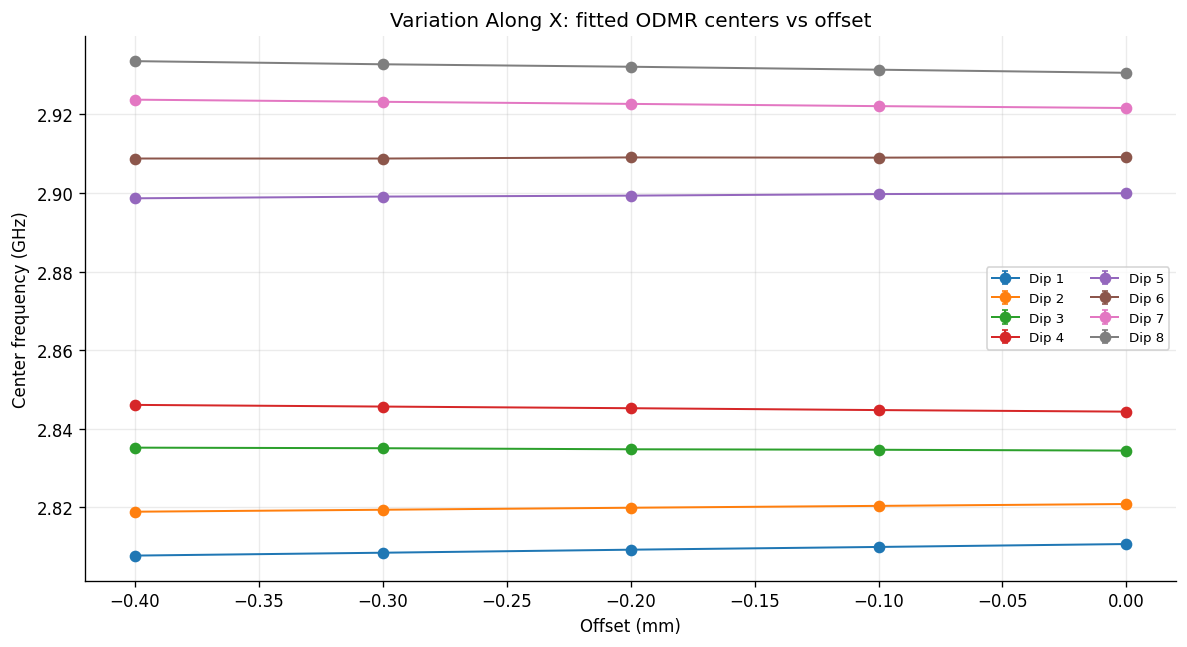

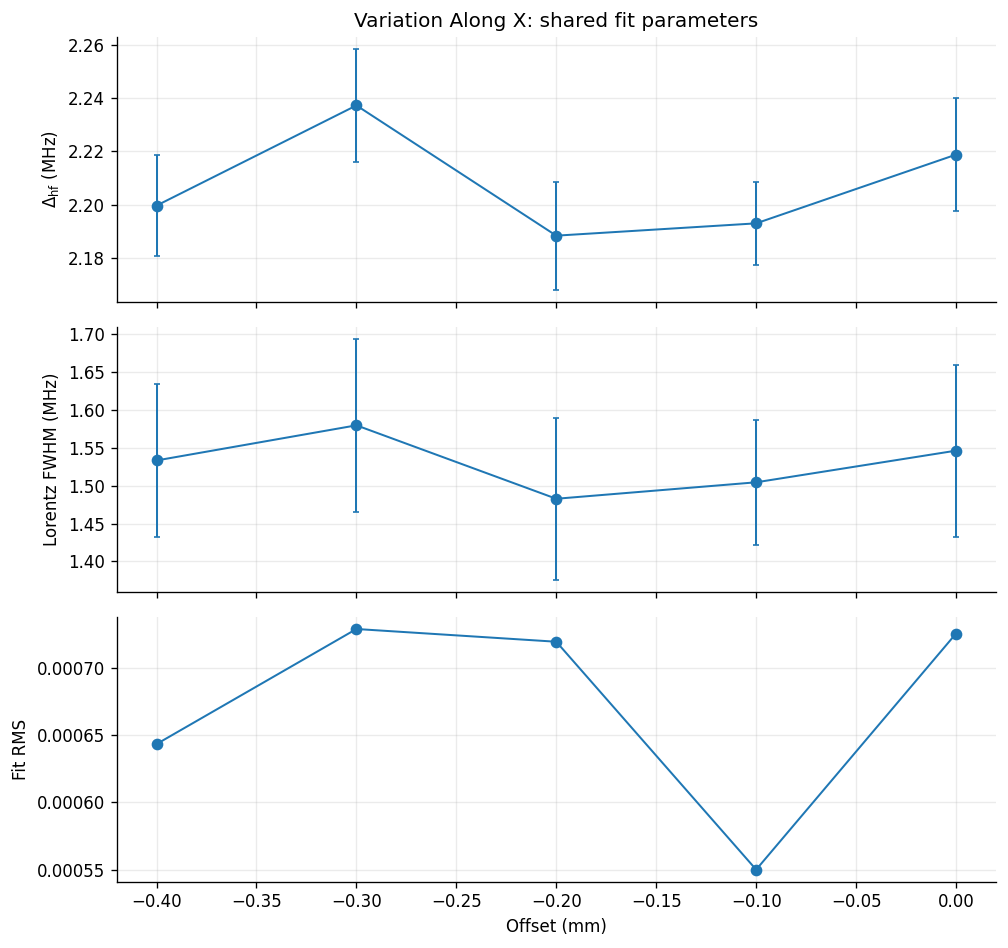

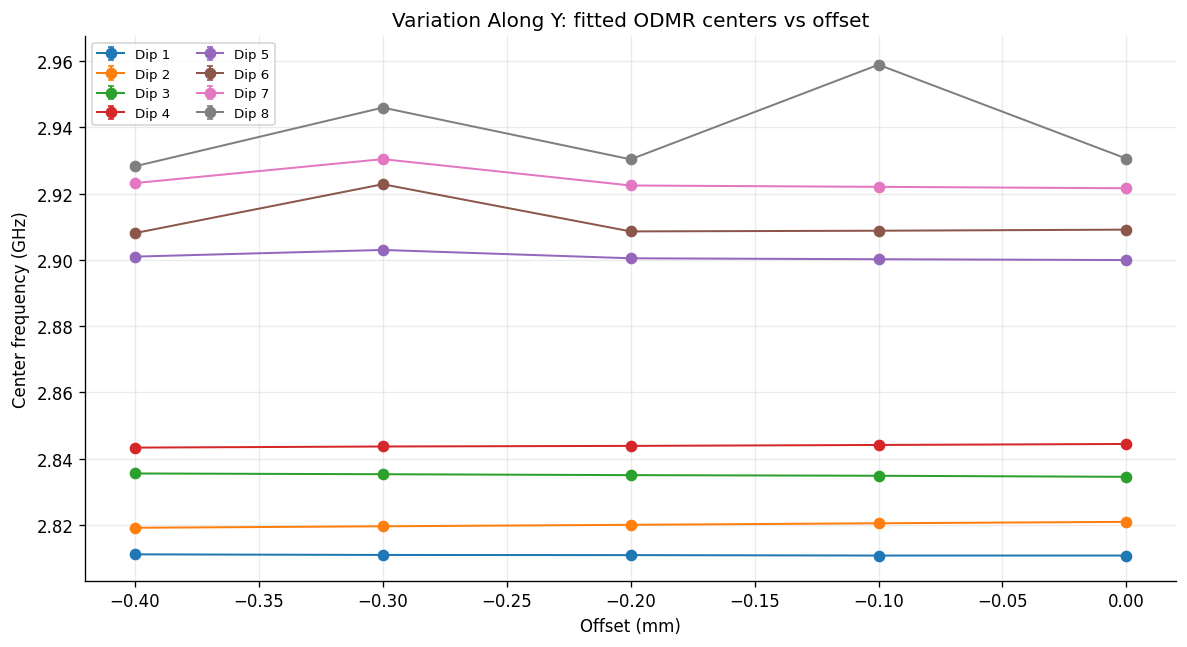

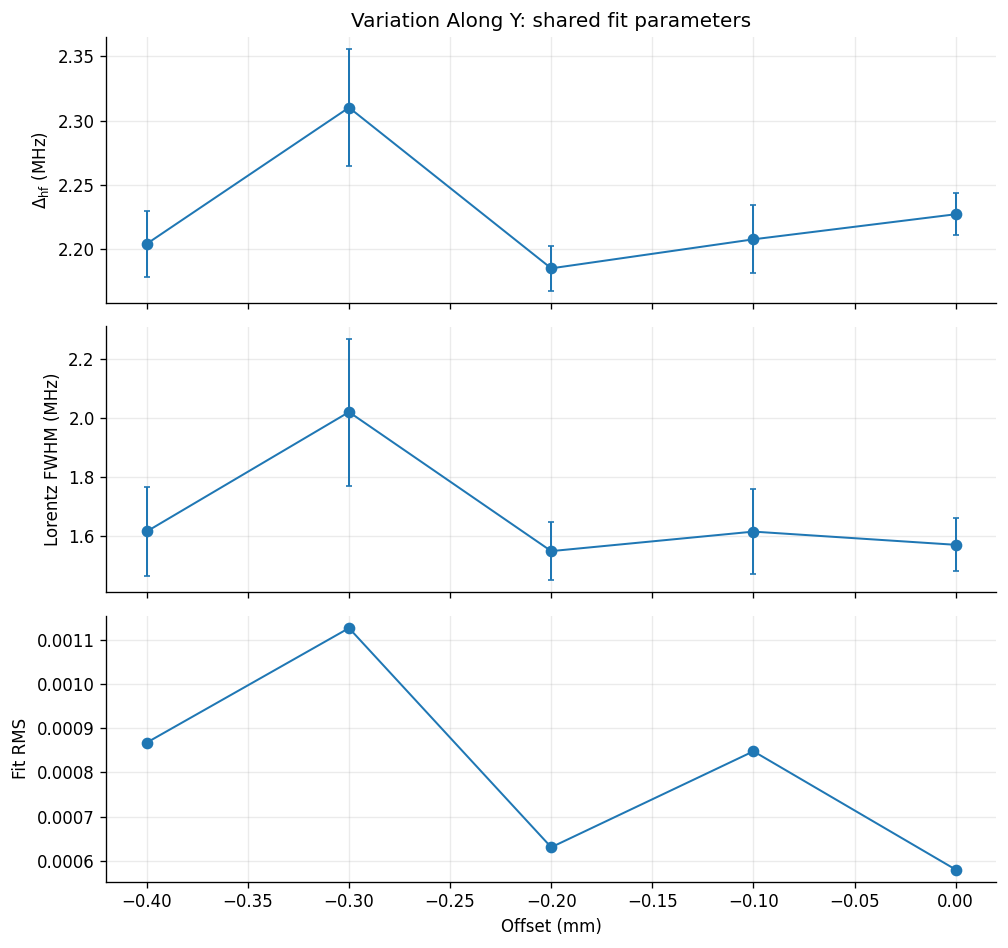

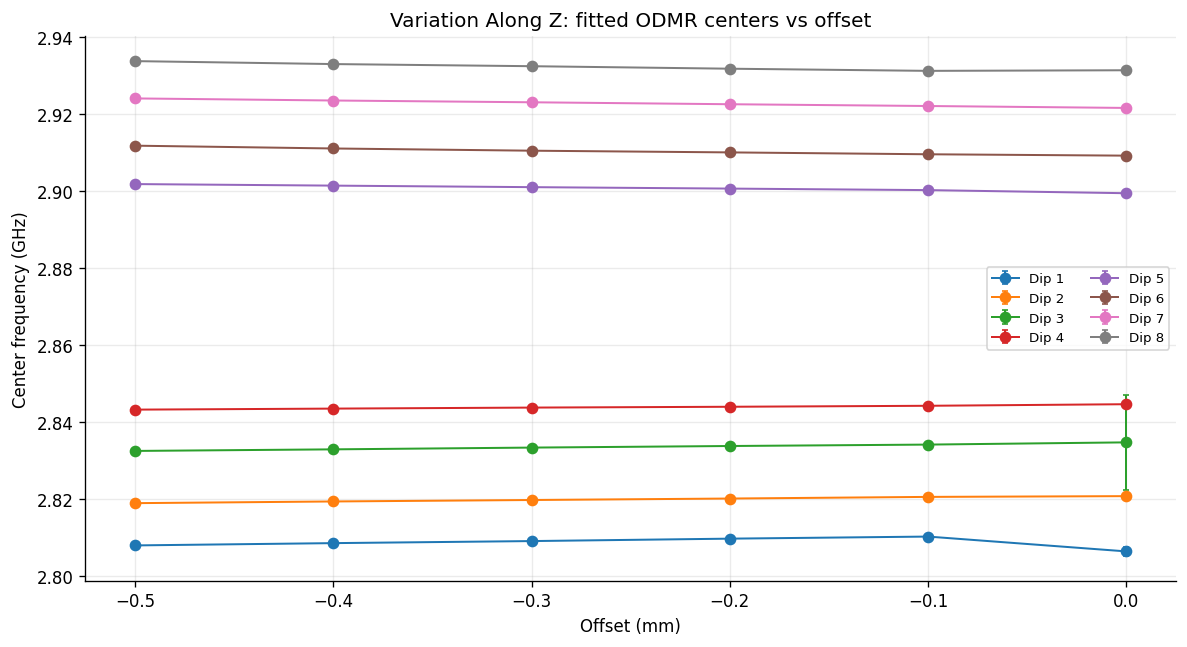

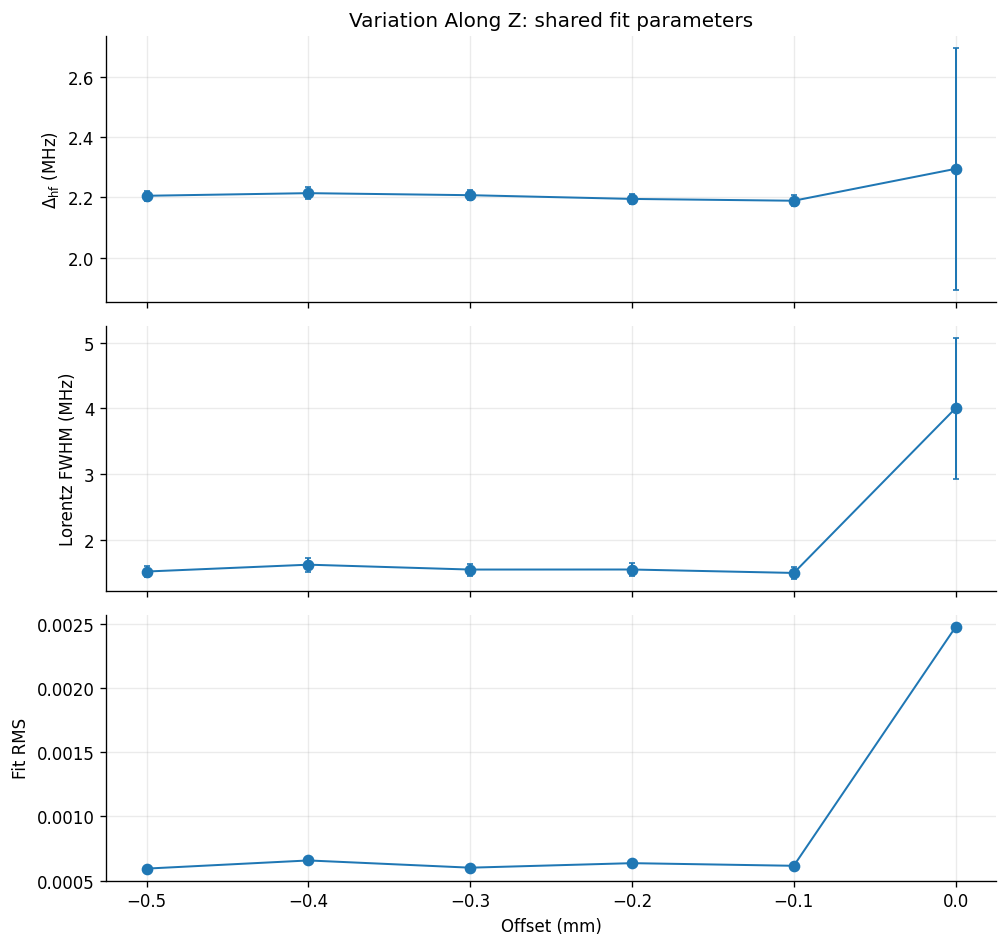

In [21]:
for variation in summary_df["variation"].dropna().unique():
    plot_center_trends(summary_df, variation)
    plot_global_parameter_trends(summary_df, variation)
